In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
epsilon1 = sp.Symbol("epsilon1", real=True, positive=True)
epsilon2 = sp.Symbol("epsilon2", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
Delta = sp.Symbol("Delta", real=True, positive=True)
Delta1, Delta2, Delta3  = sp.symbols("Delta1 Delta2 Delta3", real=True, positive=True)
Delta31, Delta32, Delta21 = sp.symbols("Delta31 Delta32 Delta21", real=True, positive=True)
t = sp.Symbol("t", real=True, positive=True)

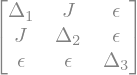

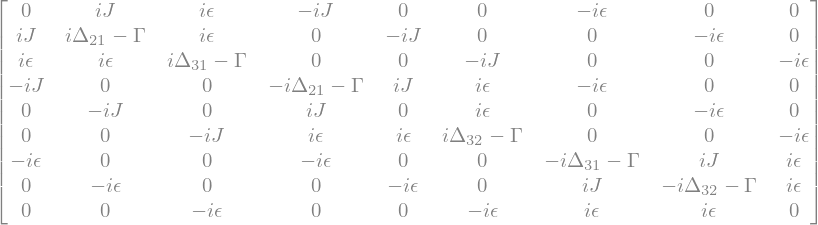

In [4]:
H = sp.Matrix([[Delta1, J, epsilon], [J, Delta2, epsilon], [epsilon, epsilon, Delta3]])
L, rho = lindbladian(3, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})

# writing in terms of site energy differences
L = L.subs({Delta3-Delta1:Delta31,Delta3-Delta2:Delta32, Delta2-Delta1:Delta21})

display(H)
display(L)

In [12]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ").replace("Delta31", "θ").replace("Delta32", "τ").replace("Delta21", "β")

'{{0, I*J, I*ϵ, -I*J, 0, 0, -I*ϵ, 0, 0}, {I*J, I*β - Γ, I*ϵ, 0, -I*J, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, I*θ - Γ, 0, 0, -I*J, 0, 0, -I*ϵ}, {-I*J, 0, 0, -I*β - Γ, I*J, I*ϵ, -I*ϵ, 0, 0}, {0, -I*J, 0, I*J, 0, I*ϵ, 0, -I*ϵ, 0}, {0, 0, -I*J, I*ϵ, I*ϵ, I*τ - Γ, 0, 0, -I*ϵ}, {-I*ϵ, 0, 0, -I*ϵ, 0, 0, -I*θ - Γ, I*J, I*ϵ}, {0, -I*ϵ, 0, 0, -I*ϵ, 0, I*J, -I*τ - Γ, I*ϵ}, {0, 0, -I*ϵ, 0, 0, -I*ϵ, I*ϵ, I*ϵ, 0}}'

# eigenvalue splitting

numerically computed evals using mathematica code...

/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


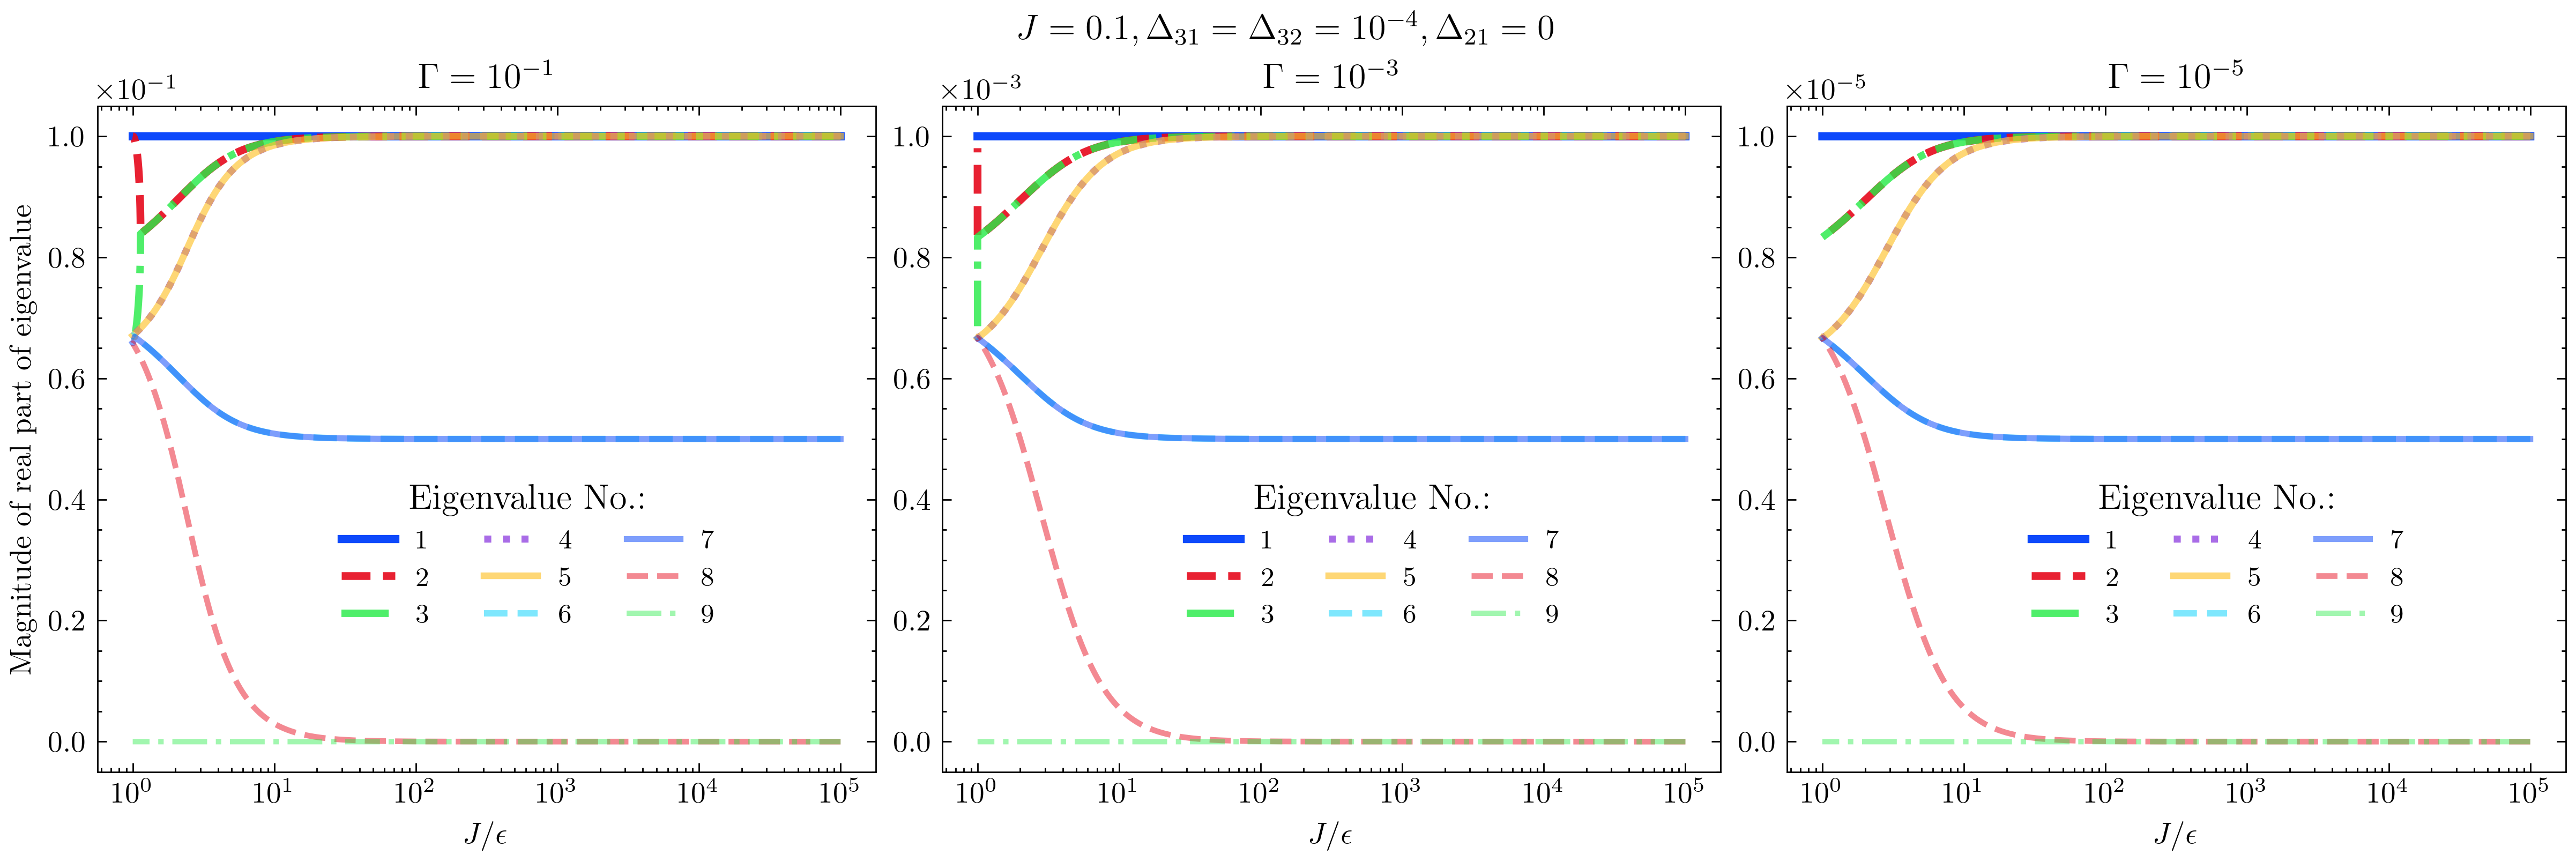

In [3]:
J_val = 0.1


datas = [
    np.loadtxt("gamma=1e-1; J=0.1; delta_32=delta_31=1e-4; delta_21=0.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-3; J=0.1; delta_32=delta_31=1e-4; delta_21=0.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-5; J=0.1; delta_32=delta_31=1e-4; delta_21=0.dat", dtype=np.complex128),
]
gammas = [
    1e-1,
    1e-3,
    1e-5,
]



fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')
plt.style.use(['science', 'high-vis'])



        
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 1:]
    
    for i in range(evals.shape[1]//2):
        axs[col].plot(J_val/eps,
                       np.abs(evals[:, 2*i]),
                        label=f"{i+1}",
                        linewidth=2.75*0.95**i,
                        alpha=1*0.9**i)

    axs[col].legend(title='Eigenvalue No.:', title_fontsize=12, fontsize=9, ncol=3, loc=(0.3, 0.2)) # plotting legend
    axs[col].set_xscale('log') # setting log scale for x axis
    axs[col].set_xlabel(r"$J / \epsilon$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')

axs[0].set_ylabel('Magnitude of real part of eigenvalue')  # labelling y axis
fig.suptitle(fr'$J={J_val}$' + r'$, \Delta_{31} = \Delta_{32} = 10^{-4}, \Delta_{21} = 0$')      
fig.savefig("splitting.pdf")
